In [2]:
# -----------------------------------------------
# Imports and setup — identical to Notebook 09
# -----------------------------------------------
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap.umap_ as umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    det_curve,
)
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

os.chdir("..")

# -----------------------------------------------
# Load real training embeddings and splits
# -----------------------------------------------
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal   = np.load("data/processed/embeddings/X_cal.npy")
y_cal   = np.load("data/processed/embeddings/y_cal.npy")
X_test  = np.load("data/processed/embeddings/X_test.npy")
y_test  = np.load("data/processed/embeddings/y_test.npy")

print(f"Train: {X_train.shape} | Positives: {y_train.sum()}")
print(f"Cal:   {X_cal.shape}   | Positives: {y_cal.sum()}")
print(f"Test:  {X_test.shape}  | Positives: {y_test.sum()}")

# -----------------------------------------------
# Load Notebook 09 baseline metrics for comparison
# -----------------------------------------------
with open("data/results/metrics_09_baseline.json") as f:
    baseline_metrics = json.load(f)

print("\nNotebook 09 baseline loaded:")
for name, m in baseline_metrics.items():
    print(f"  {name}: F1={m['f1']:.3f} | P={m['precision']:.3f} | R={m['recall']:.3f}")

Train: (69510, 384) | Positives: 674
Cal:   (9931, 384)   | Positives: 96
Test:  (19861, 384)  | Positives: 192

Notebook 09 baseline loaded:
  LR: F1=0.152 | P=0.085 | R=0.729
  MLP-1: F1=0.270 | P=0.190 | R=0.464
  MLP-2: F1=0.207 | P=0.134 | R=0.448


In [3]:
# -----------------------------------------------
# MLP architecture and sklearn wrapper
# Identical to Notebook 09 — copied here for
# self-containment. hidden_dims controls depth:
#   [256]      -> MLP-1
#   [256, 128] -> MLP-2
# -----------------------------------------------
def optimal_threshold_f1(
    y_true, y_scores,
    thresholds=np.arange(0.01, 0.70, 0.01),
):
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1


class MLP(nn.Module):
    def __init__(self, input_dim=384, hidden_dims=[256], dropout=0.1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class MLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self, hidden_dims=[256], n_epochs=50, lr=1e-3,
        batch_size=256, patience=5, dropout=0.1, random_state=SEED,
    ):
        self.hidden_dims   = hidden_dims
        self.n_epochs      = n_epochs
        self.lr            = lr
        self.batch_size    = batch_size
        self.patience      = patience
        self.dropout       = dropout
        self.random_state  = random_state
        self.classes_      = np.array([0, 1])

    def fit(self, X, y, X_cal=None, y_cal=None):
        torch.manual_seed(self.random_state)
        n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
        class_weights = torch.tensor(
            [1.0 / n_neg, 1.0 / n_pos], dtype=torch.float
        )
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.model_ = MLP(X.shape[1], self.hidden_dims, self.dropout)
        optimizer = AdamW(
            self.model_.parameters(), lr=self.lr, weight_decay=1e-4
        )
        loader = DataLoader(
            TensorDataset(
                torch.tensor(X, dtype=torch.float),
                torch.tensor(y, dtype=torch.long),
            ),
            batch_size=self.batch_size, shuffle=True,
        )
        best_cal_f1, best_weights, no_improve = 0.0, None, 0
        for epoch in range(self.n_epochs):
            self.model_.train()
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(X_batch), y_batch)
                loss.backward()
                optimizer.step()
            if X_cal is not None and y_cal is not None:
                _, cal_f1 = optimal_threshold_f1(
                    y_cal, self.predict_proba(X_cal)[:, 1]
                )
                if cal_f1 > best_cal_f1:
                    best_cal_f1 = cal_f1
                    best_weights = {
                        k: v.clone() for k, v in self.model_.state_dict().items()
                    }
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= self.patience:
                        print(f"  Early stopping at epoch {epoch+1} "
                              f"(best cal F1: {best_cal_f1:.4f})")
                        break
        if best_weights is not None:
            self.model_.load_state_dict(best_weights)
        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            probs = torch.softmax(
                self.model_(torch.tensor(X, dtype=torch.float)), dim=1
            ).numpy()
        return probs

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def evaluate_classifier(clf, X_train, y_train, X_cal, y_cal,
                         X_test, y_test, name="Classifier"):
    if isinstance(clf, MLPClassifier):
        clf.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
    else:
        clf.fit(X_train, y_train)
    cal_scores  = clf.predict_proba(X_cal)[:, 1]
    t, cal_f1   = optimal_threshold_f1(y_cal, cal_scores)
    test_scores = clf.predict_proba(X_test)[:, 1]
    y_pred      = (test_scores >= t).astype(int)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f"\n=== {name} (threshold={t:.2f}) ===")
    print(classification_report(y_test, y_pred, digits=3))
    return {
        'name': name, 'clf': clf, 'threshold': t,
        'cal_f1': cal_f1, 'test_scores': test_scores,
        'y_pred': y_pred, 'precision': prec, 'recall': rec, 'f1': f1,
    }

print("Utilities and model classes defined.")

Utilities and model classes defined.


In [4]:
# -----------------------------------------------
# Load and encode synthetic candidates
# Both parquets embedded using the same frozen
# encoder used throughout — ensures filter
# operates in the same embedding space as
# real training data
# -----------------------------------------------
encoder = SentenceTransformer('all-MiniLM-L6-v2')

# Load parquets
df_cot     = pd.read_parquet("data/synthetic/positive_cot_70b_raw.parquet")

print(f"CoT candidates:     {len(df_cot)}")

# Encode

print("Encoding CoT candidates...")
X_cot = encoder.encode(
    df_cot['sentence'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
)

print(f"CoT embeddings:     {X_cot.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 607.94it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CoT candidates:     674
Encoding CoT candidates...


Batches: 100%|██████████| 22/22 [00:03<00:00,  6.76it/s]

CoT embeddings:     (674, 384)


In [5]:
# -----------------------------------------------
# Cosine similarity filter
# For each synthetic candidate, compute max
# cosine similarity to any real positive in
# the training set. Retain candidates above
# threshold τ — model agnostic, purely geometric.
# -----------------------------------------------
from sklearn.metrics.pairwise import cosine_similarity

# Real positive embeddings — filter reference
X_real_pos = X_train[y_train == 1]  # shape (674, 384)
print(f"Real positive embeddings for filtering: {X_real_pos.shape}")

def cosine_filter(
    X_syn: np.ndarray,
    X_real_pos: np.ndarray,
    thresholds: list = [0.5, 0.6, 0.7, 0.8, 0.9],
) -> dict:
    """
    For each synthetic candidate, compute max cosine similarity
    to any real positive. Report survival counts at each threshold.

    Args:
        X_syn:      Synthetic candidate embeddings (n, 384)
        X_real_pos: Real positive embeddings (674, 384)
        thresholds: List of similarity thresholds to evaluate

    Returns:
        Dict mapping threshold -> boolean mask of survivors
    """
    # Pairwise cosine similarity: (n_syn, n_real_pos)
    # max over real positives gives each candidate's best match score
    sim_matrix  = cosine_similarity(X_syn, X_real_pos)
    max_sim     = sim_matrix.max(axis=1)  # shape (n_syn,)

    print(f"\nSimilarity distribution:")
    print(f"  mean:  {max_sim.mean():.3f}")
    print(f"  std:   {max_sim.std():.3f}")
    print(f"  min:   {max_sim.min():.3f}")
    print(f"  max:   {max_sim.max():.3f}")

    results = {}
    for τ in thresholds:
        mask = max_sim >= τ
        results[τ] = mask
        print(f"  τ={τ}: {mask.sum()} survivors "
              f"({100*mask.mean():.1f}%)")
    return results, max_sim

print("\n=== CoT filter ===")
cot_masks, cot_sim = cosine_filter(X_cot, X_real_pos)

Real positive embeddings for filtering: (674, 384)

=== CoT filter ===

Similarity distribution:
  mean:  0.735
  std:   0.104
  min:   0.480
  max:   0.973
  τ=0.5: 668 survivors (99.1%)
  τ=0.6: 608 survivors (90.2%)
  τ=0.7: 412 survivors (61.1%)
  τ=0.8: 204 survivors (30.3%)
  τ=0.9: 26 survivors (3.9%)


In [6]:
# -----------------------------------------------
# Apply τ=0.8 filter and construct augmented
# training sets for both conditions
# -----------------------------------------------
TAU = 0.6

# Apply masks
cot_mask     = cot_masks[TAU]

X_cot_filtered = X_cot[cot_mask]
y_cot_filtered = np.ones(cot_mask.sum(), dtype=int)

print(f"τ={TAU} survivors:")
print(f"  CoT:     {cot_mask.sum()} / {len(cot_mask)}")

# Augmented training sets
X_train_cot = np.vstack([X_train, X_cot_filtered])
y_train_cot = np.concatenate([y_train, y_cot_filtered])

print(f"\nAugmented training sets:")
print(f"  CoT:     {X_train_cot.shape} | "
      f"Positives: {y_train_cot.sum()} | "
      f"Ratio: {(y_train_cot==0).sum()/y_train_cot.sum():.1f}:1")

τ=0.6 survivors:
  CoT:     608 / 674

Augmented training sets:
  CoT:     (70118, 384) | Positives: 1282 | Ratio: 53.7:1


Fitting UMAP for 70B CoT filtered synthetics...


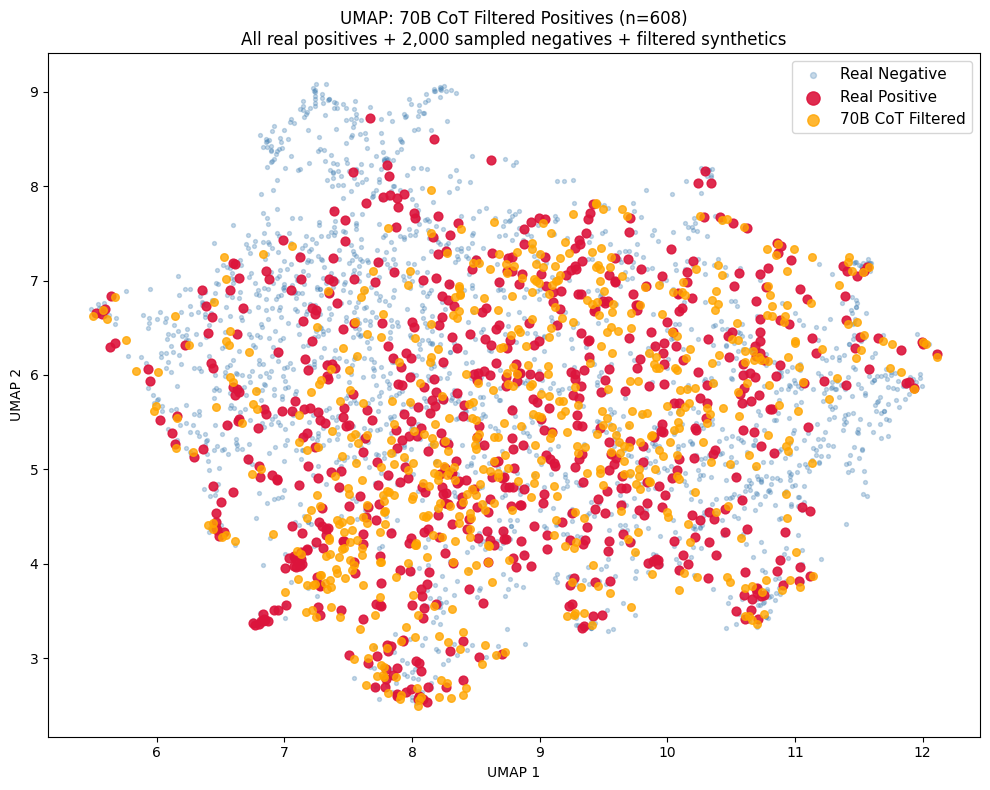

UMAP saved.


In [10]:
# -----------------------------------------------
# UMAP: 70B CoT filtered synthetics overlaid
# on real training data
# All real positives + 2000 sampled negatives
# + filtered 70B CoT synthetic positives
# -----------------------------------------------
np.random.seed(SEED)
pos_idx        = np.where(y_train == 1)[0]
neg_idx        = np.where(y_train == 0)[0]
neg_sample_idx = np.random.choice(neg_idx, size=2000, replace=False)

fig, ax = plt.subplots(figsize=(10, 8))

X_plot = np.vstack([
    X_train[pos_idx],
    X_train[neg_sample_idx],
    X_cot_filtered,
])
y_plot = (
    ['Real Positive']     * len(pos_idx) +
    ['Real Negative']     * len(neg_sample_idx) +
    ['70B CoT Filtered']  * len(X_cot_filtered)
)

print("Fitting UMAP for 70B CoT filtered synthetics...")
reducer  = umap.UMAP(n_components=2, random_state=SEED,
                     n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(X_plot)

color_map = {
    'Real Negative':    'steelblue',
    'Real Positive':    'crimson',
    '70B CoT Filtered': 'orange',
}
size_map = {
    'Real Negative':    8,
    'Real Positive':    40,
    '70B CoT Filtered': 30,
}
alpha_map = {
    'Real Negative':    0.3,
    'Real Positive':    0.9,
    '70B CoT Filtered': 0.8,
}

for cat in ['Real Negative', 'Real Positive', '70B CoT Filtered']:
    mask = np.array(y_plot) == cat
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1],
        c=color_map[cat], s=size_map[cat],
        alpha=alpha_map[cat], label=cat,
    )

ax.set_title(
    f'UMAP: 70B CoT Filtered Positives (n={len(X_cot_filtered)})\n'
    'All real positives + 2,000 sampled negatives + filtered synthetics',
    fontsize=12,
)
ax.legend(fontsize=11, markerscale=1.5)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig("data/results/umap_positive_aug_cot_70b.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("UMAP saved.")

In [8]:
# -----------------------------------------------
# Train all three classifiers on each augmented
# training set. Three conditions total:
#   1. Vanilla filtered (τ=0.8, n=278)
#   2. CoT filtered (τ=0.8, n=306)
# Baseline results loaded from Notebook 09.
# -----------------------------------------------

conditions = {
    'CoT':     (X_train_cot,     y_train_cot),
}

all_results = {}

for cond_name, (X_tr, y_tr) in conditions.items():
    print(f"\n{'='*60}")
    print(f"Condition: {cond_name} augmented")
    print(f"{'='*60}")
    all_results[cond_name] = {}

    # LR
    print("\nTraining LR...")
    all_results[cond_name]['LR'] = evaluate_classifier(
        LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=SEED
        ),
        X_tr, y_tr, X_cal, y_cal, X_test, y_test,
        name=f"LR ({cond_name})",
    )

    # MLP-1
    print("\nTraining MLP-1...")
    all_results[cond_name]['MLP-1'] = evaluate_classifier(
        MLPClassifier(hidden_dims=[256], random_state=SEED),
        X_tr, y_tr, X_cal, y_cal, X_test, y_test,
        name=f"MLP-1 ({cond_name})",
    )

    # MLP-2
    print("\nTraining MLP-2...")
    all_results[cond_name]['MLP-2'] = evaluate_classifier(
        MLPClassifier(hidden_dims=[256, 128], random_state=SEED),
        X_tr, y_tr, X_cal, y_cal, X_test, y_test,
        name=f"MLP-2 ({cond_name})",
    )


Condition: CoT augmented

Training LR...

=== LR (CoT) (threshold=0.69) ===
              precision    recall  f1-score   support

           0      0.996     0.939     0.967     19669
           1      0.094     0.651     0.165       192

    accuracy                          0.936     19861
   macro avg      0.545     0.795     0.566     19861
weighted avg      0.988     0.936     0.959     19861


Training MLP-1...
  Early stopping at epoch 29 (best cal F1: 0.2643)

=== MLP-1 (CoT) (threshold=0.59) ===
              precision    recall  f1-score   support

           0      0.994     0.986     0.990     19669
           1      0.223     0.422     0.292       192

    accuracy                          0.980     19861
   macro avg      0.609     0.704     0.641     19861
weighted avg      0.987     0.980     0.983     19861


Training MLP-2...
  Early stopping at epoch 19 (best cal F1: 0.2601)

=== MLP-2 (CoT) (threshold=0.67) ===
              precision    recall  f1-score   support

Condition            Classifier    Precision   Recall       F1
---------------------------------------------------------------------------
Baseline             LR                0.085    0.729    0.152
Baseline             MLP-1             0.190    0.464    0.270
Baseline             MLP-2             0.134    0.448    0.207
70B CoT aug          LR                0.094    0.651    0.165
70B CoT aug          MLP-1             0.223    0.422    0.292
70B CoT aug          MLP-2             0.164    0.422    0.236
Retraining baselines for DET reference curves...
  Early stopping at epoch 25 (best cal F1: 0.2541)
  Early stopping at epoch 22 (best cal F1: 0.2266)


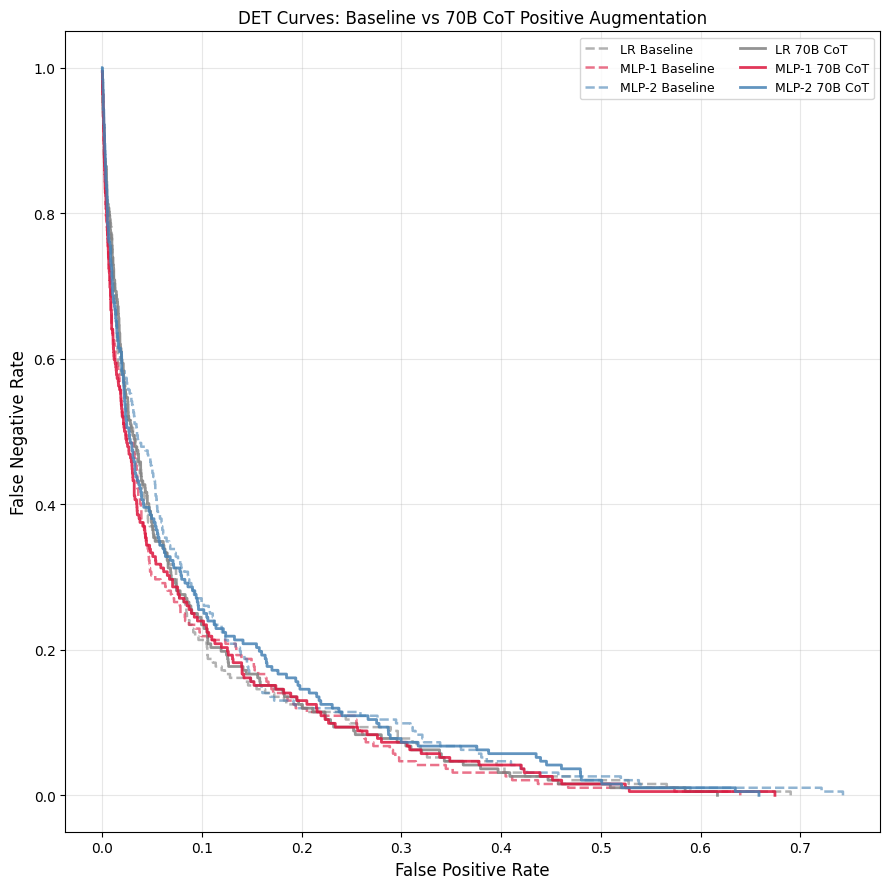

DET curves saved.
Metrics saved to data/results/metrics_cot_70b.json


In [9]:
# -----------------------------------------------
# Summary table
# -----------------------------------------------
print("=" * 75)
print(f"{'Condition':<20} {'Classifier':<12} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8}")
print("-" * 75)

# Notebook 09 baseline
for clf_name, m in baseline_metrics.items():
    print(f"{'Baseline':<20} {clf_name:<12} {m['precision']:>10.3f} "
          f"{m['recall']:>8.3f} {m['f1']:>8.3f}")

# 70B CoT condition only
for clf_name, r in all_results['CoT'].items():
    print(f"{'70B CoT aug':<20} {clf_name:<12} {r['precision']:>10.3f} "
          f"{r['recall']:>8.3f} {r['f1']:>8.3f}")
print("=" * 75)

# -----------------------------------------------
# DET curves — baseline vs 70B CoT only
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))

clf_colors = {'LR': 'gray', 'MLP-1': 'crimson', 'MLP-2': 'steelblue'}

# Retrain baselines for DET reference curves
print("Retraining baselines for DET reference curves...")
for clf_name, hidden_dims in [('LR', None), ('MLP-1', [256]), ('MLP-2', [256, 128])]:
    if clf_name == 'LR':
        clf = LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=SEED
        )
        clf.fit(X_train, y_train)
    else:
        clf = MLPClassifier(hidden_dims=hidden_dims, random_state=SEED)
        clf.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)

    scores = clf.predict_proba(X_test)[:, 1]
    fpr, fnr, _ = det_curve(y_test, scores)
    ax.plot(fpr, fnr,
            color=clf_colors[clf_name],
            linestyle='--',
            linewidth=1.8,
            label=f"{clf_name} Baseline",
            alpha=0.6)

# 70B CoT augmented conditions
for clf_name, r in all_results['CoT'].items():
    fpr, fnr, _ = det_curve(y_test, r['test_scores'])
    ax.plot(fpr, fnr,
            color=clf_colors[clf_name],
            linestyle='-',
            linewidth=2,
            label=f"{clf_name} 70B CoT",
            alpha=0.85)

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("False Negative Rate", fontsize=12)
ax.set_title(
    "DET Curves: Baseline vs 70B CoT Positive Augmentation",
    fontsize=12,
)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/results/det_curves_cot_70b.png", dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

# -----------------------------------------------
# Save metrics
# -----------------------------------------------
metrics_cot_70b = {
    clf_name: {
        'precision': round(r['precision'], 4),
        'recall':    round(r['recall'], 4),
        'f1':        round(r['f1'], 4),
        'threshold': round(r['threshold'], 4),
        'cal_f1':    round(r['cal_f1'], 4),
    }
    for clf_name, r in all_results['CoT'].items()
}

with open("data/results/metrics_cot_70b.json", "w") as f:
    json.dump(metrics_cot_70b, f, indent=2)
print("Metrics saved to data/results/metrics_cot_70b.json")